In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
%matplotlib inline

In [2]:
df = pd.read_csv("../global_bleaching_environmental.csv")

/tmp/ipykernel_32535/1993203370.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../global_bleaching_environmental.csv")


In [3]:
numeric_cols = ['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
       'Turbidity', 'Cyclone_Frequency', 'Date_Year', 'Depth_m',
       'Percent_Bleaching', 'ClimSST',
       'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum',
       'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation',
       'Windspeed', 'SSTA', 'SSTA_Standard_Deviation',
       'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency',
       'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax',
       'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation',
       'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation',
       'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency',
       'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean',] # ssta_mean = 0

drop_columns = ['Site_ID', 'Sample_ID', 'Data_Source','Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Date_Day',
       'Substrate_Name', 'Site_Comments', 'Sample_Comments',
       'Bleaching_Comments', 'Bleaching_Level', 'Percent_Cover', 'SSTA_Mean', 'Exposure',
       ] # Exposure - interesting

df.drop(columns= drop_columns, inplace= True)


for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df[df['Date_Year'] >= 1997]
df = df[df['SSTA'] > 0]
df = df.dropna(subset=['Percent_Bleaching'])

# df = df.dropna()

In [4]:
df.shape

(21928, 42)

In [5]:
month_dummies = pd.get_dummies(df['Date_Month'], prefix='Month', drop_first=False)
df = pd.concat([df, month_dummies], axis=1)
df = df.drop(columns=["Date", 'Date_Month', 'Date_Year'])

In [7]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore',
       'Turbidity', 'Cyclone_Frequency', 'Depth_m', 'Percent_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Month_1', 'Month_2', 'Month_3', 'Month_4',
       'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10',
       'Month_11', 'Month_12'],


# PCA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [11]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [12]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

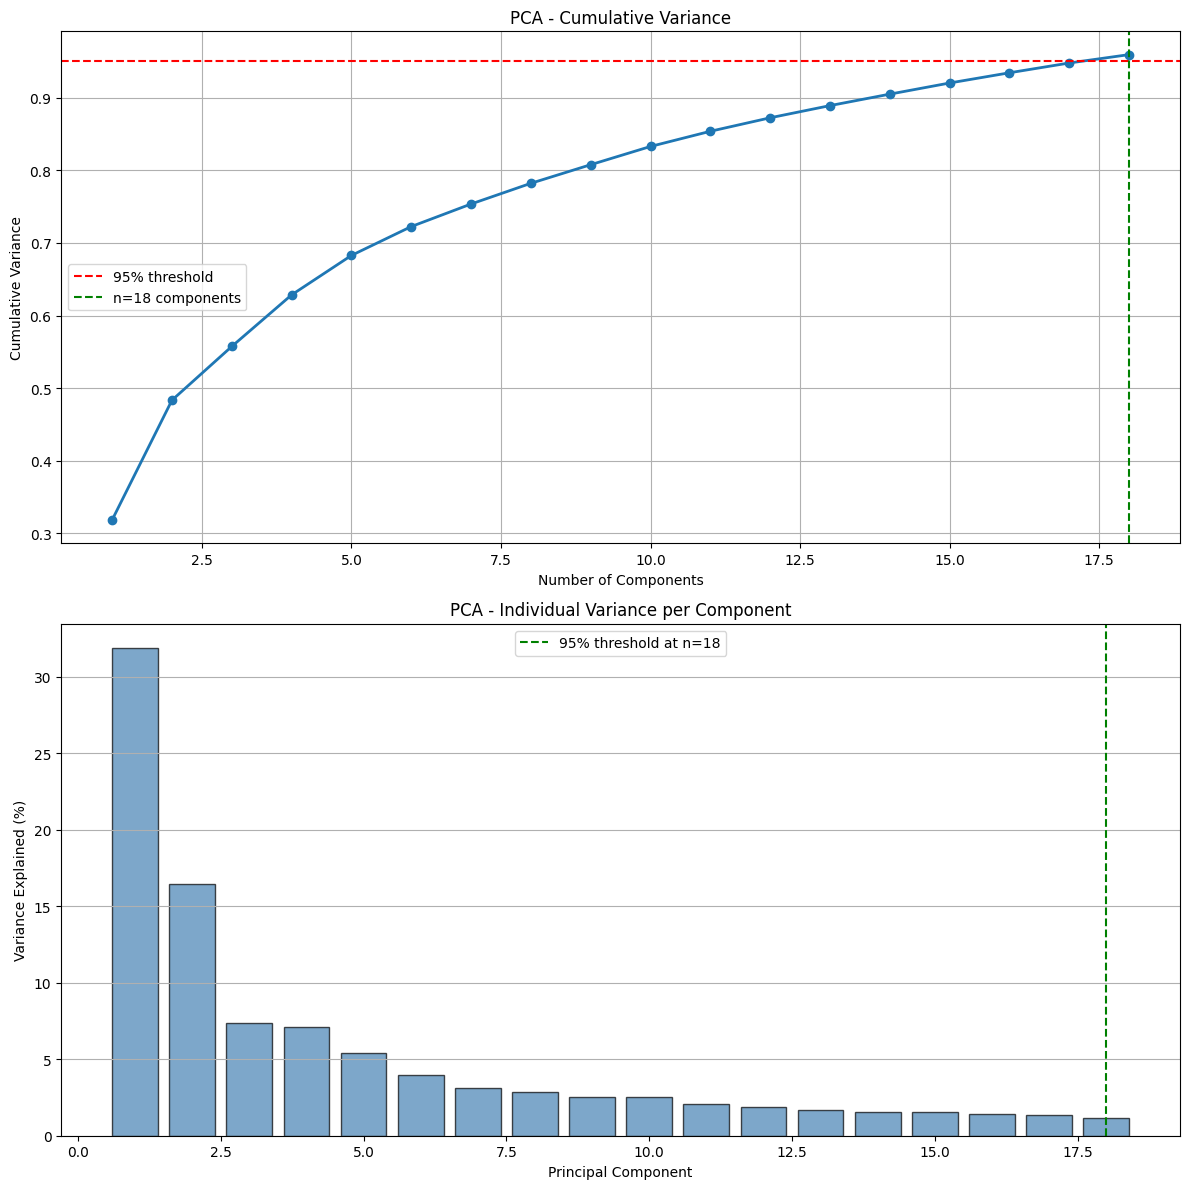

✅ Components needed for 95% variance: 18
✅ Variance explained by 18 components: 0.9591


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [14]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# lazyPredict

In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

In [16]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import (HistGradientBoostingRegressor, ExtraTreesRegressor,
                              RandomForestRegressor, BaggingRegressor, VotingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# OpTuna

In [19]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [20]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-05 23:55:28,375] A new study created in memory with name: no-name-7dc4988e-0116-4019-a6e9-e18c752c5ba8
[I 2026-05-05 23:55:29,859] Trial 0 finished with value: 0.38692326444815667 and parameters: {'n_estimators': 244, 'max_depth': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.38692326444815667.
[I 2026-05-05 23:55:31,836] Trial 1 finished with value: 0.6066226825348902 and parameters: {'n_estimators': 230, 'max_depth': 26, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.6066226825348902.
[I 2026-05-05 23:55:33,523] Trial 2 finished with value: 0.5657806024812442 and parameters: {'n_estimators': 203, 'max_depth': 21, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.6066226825348902.
[I 2026-05-05 23:55:34,231] Trial 3 finished with value: 0.1458898740982237 and parameters: {'n_estimators': 77, 'max_depth': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value

========== ET BEST ==========
{'n_estimators': 144, 'max_depth': 30, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.6160


In [21]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-05 23:56:35,529] A new study created in memory with name: no-name-9aa9fee0-1a15-48d9-aab0-08d581421bc7
[I 2026-05-05 23:56:38,663] Trial 0 finished with value: 0.36450434440966567 and parameters: {'n_estimators': 263, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.36450434440966567.
[I 2026-05-05 23:56:41,815] Trial 1 finished with value: 0.5586644479903494 and parameters: {'n_estimators': 142, 'max_depth': 35, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5586644479903494.
[I 2026-05-05 23:56:43,911] Trial 2 finished with value: 0.4002744658659342 and parameters: {'n_estimators': 145, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5586644479903494.
[I 2026-05-05 23:56:45,299] Trial 3 finished with value: 0.5092296579929956 and parameters: {'n_estimators': 74, 'max_depth': 15, 'mi

========== RF BEST ==========
{'n_estimators': 290, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.5936


In [22]:
def bagging_objective(trial):
    base = DecisionTreeRegressor(
        max_depth=trial.suggest_int("base_max_depth", 5, 40),
        random_state=42
    )
    model = BaggingRegressor(
        estimator    = base,
        n_estimators = trial.suggest_int("n_estimators", 10, 200),
        max_samples  = trial.suggest_float("max_samples", 0.5, 1.0),
        max_features = trial.suggest_float("max_features", 0.5, 1.0),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

bagging_study = optuna.create_study(direction="maximize")
bagging_study.optimize(bagging_objective, n_trials=50)
print("========== BAGGING BEST ==========")
print(bagging_study.best_params)
print(f"Best R²: {bagging_study.best_value:.4f}")

[I 2026-05-06 00:00:05,232] A new study created in memory with name: no-name-19bf3058-3332-4393-a805-b87539ac5bc4
[I 2026-05-06 00:00:13,555] Trial 0 finished with value: 0.5661068303777134 and parameters: {'base_max_depth': 17, 'n_estimators': 88, 'max_samples': 0.9239901988514595, 'max_features': 0.6467982382708276}. Best is trial 0 with value: 0.5661068303777134.
[I 2026-05-06 00:00:19,060] Trial 1 finished with value: 0.5263392890264792 and parameters: {'base_max_depth': 12, 'n_estimators': 78, 'max_samples': 0.8526872368714626, 'max_features': 0.8436325823910055}. Best is trial 0 with value: 0.5661068303777134.
[I 2026-05-06 00:00:21,946] Trial 2 finished with value: 0.3333182077759511 and parameters: {'base_max_depth': 5, 'n_estimators': 65, 'max_samples': 0.60112860826784, 'max_features': 0.8056874286998733}. Best is trial 0 with value: 0.5661068303777134.
[I 2026-05-06 00:00:28,653] Trial 3 finished with value: 0.5576042793353295 and parameters: {'base_max_depth': 35, 'n_estima

========== BAGGING BEST ==========
{'base_max_depth': 33, 'n_estimators': 135, 'max_samples': 0.9930215377876219, 'max_features': 0.9281136621179259}
Best R²: 0.5879


# Start

In [23]:
et_model = ExtraTreesRegressor(
    n_estimators=144,
    max_depth=30,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 144, 'max_depth': 30, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

rf_model = RandomForestRegressor(
    n_estimators=290,
    max_depth=38,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 290, 'max_depth': 38, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=33, random_state=42),
    n_estimators=135,
    max_samples=0.993,
    max_features=0.928,
    n_jobs=-1,
    random_state=42
)
# {'base_max_depth': 33, 'n_estimators': 135, 'max_samples': 0.9930215377876219, 'max_features': 0.9281136621179259}

In [24]:
voting_model = VotingRegressor([
    ('et',  et_model),
    ('rf',  rf_model),
    ('bag', bagging_model)
])

# Train all 5
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
bagging_model.fit(X_train_pca, y_train)
voting_model.fit(X_train_pca, y_train)

# Evaluate
models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'Bagging':              bagging_model,
    'Voting (Ensemble)':    voting_model
}

print("=" * 65)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 65)
print(f"{'Model':<22}{'R²':>10}{'RMSE':>12}{'MAE':>10}{'Acc%':>10}")
print("-" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<22}{r2:>10.4f}{rmse:>12.4f}{mae:>10.4f}{100-mae:>10.2f}")
print("-" * 65)
print(f"{'Paper baseline:':<22}{0.6395:>10.4f}{12.9268:>12.4f}{'—':>10}{93.88:>10.2f}")
print("=" * 65)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
ExtraTrees                0.6684     12.1518    5.4103     94.59
RandomForest              0.6289     12.8551    6.5780     93.42
Bagging                   0.6277     12.8758    6.6288     93.37
Voting (Ensemble)         0.6509     12.4675    6.1678     93.83
-----------------------------------------------------------------
Paper baseline:           0.6395     12.9268         —     93.88


# K-Fold

In [25]:
from sklearn.model_selection import KFold

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month    = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'Bagging':              bagging_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('bag', bagging_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_no_month):
        # Split numeric and month separately
        X_fold_train, X_fold_test = X_no_month.iloc[train_idx], X_no_month.iloc[test_idx]
        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_ss)
        X_test_pca  = pca.transform(X_test_ss)

        # Reattach month columns after PCA
        n_pcs   = X_train_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([pd.DataFrame(X_train_pca, columns=pc_cols), month_fold_train], axis=1)
        X_test_final  = pd.concat([pd.DataFrame(X_test_pca,  columns=pc_cols), month_fold_test ], axis=1)

        # Train & evaluate (clone to avoid refitting same instance)
        from sklearn.base import clone
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.6544       12.6581        5.7875
RandomForest                  0.6259       13.1658        6.8424
Bagging                       0.6179       13.3072        6.9126
Voting (Ensemble)             0.6426       12.8696        6.4665
